# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [4]:
from pathlib import Path

import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv'

df = pd.read_csv(DATA_DIR / file_path,
                 na_values=' ',)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Hay 7043 filas y 33 columnas 
Hay columnas de tipo float, int y objeto
Solo se mostrabaja total charges como objeto cuando era float, pero esto a que habia varios espacios en blanco, que ya se eliminaron al cargar el dataset con espacios en blanco como datos nulos.

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [3]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [13]:
cat_vars = df.drop(columns=['CustomerID', 'Country', 'State', 'City', 'Lat Long']).select_dtypes(include='object').columns   
for var in cat_vars:
    print('\n')
    print(f'{var}: {df[var].unique()} unique values')



Gender: ['Male' 'Female'] unique values


Senior Citizen: ['No' 'Yes'] unique values


Partner: ['No' 'Yes'] unique values


Dependents: ['No' 'Yes'] unique values


Phone Service: ['Yes' 'No'] unique values


Multiple Lines: ['No' 'Yes' 'No phone service'] unique values


Internet Service: ['DSL' 'Fiber optic' 'No'] unique values


Online Security: ['Yes' 'No' 'No internet service'] unique values


Online Backup: ['Yes' 'No' 'No internet service'] unique values


Device Protection: ['No' 'Yes' 'No internet service'] unique values


Tech Support: ['No' 'Yes' 'No internet service'] unique values


Streaming TV: ['No' 'Yes' 'No internet service'] unique values


Streaming Movies: ['No' 'Yes' 'No internet service'] unique values


Contract: ['Month-to-month' 'Two year' 'One year'] unique values


Paperless Billing: ['Yes' 'No'] unique values


Payment Method: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values


Churn Label: ['Yes' 'N

- No hay valores fura de rango o imposible. 
- Count es una constante de 1 
- Las veraibles de alta cardinalidad son: 'city' y 'Lat Long'
- Clave primaria: 'CustomerID'

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [15]:
df.isnull().sum()*100/df.shape[0]

CustomerID            0.000000
Count                 0.000000
Country               0.000000
State                 0.000000
City                  0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
Longitude             0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Internet Service      0.000000
Online Security       0.000000
Online Backup         0.000000
Device Protection     0.000000
Tech Support          0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Monthly Charges       0.000000
Total Charges         0.156183
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
Churn Re

In [18]:
print(f'Numero de registros duplicados: {df.duplicated().sum()}')

Numero de registros duplicados: 0


In [17]:
cat_vars = df.drop(columns=['CustomerID', 'Country', 'State', 'City', 'Lat Long']).select_dtypes(include='object').columns   
for var in cat_vars:
    print('\n')
    print(f'{var}: {df[var].unique()} unique values')



Gender: ['Male' 'Female'] unique values


Senior Citizen: ['No' 'Yes'] unique values


Partner: ['No' 'Yes'] unique values


Dependents: ['No' 'Yes'] unique values


Phone Service: ['Yes' 'No'] unique values


Multiple Lines: ['No' 'Yes' 'No phone service'] unique values


Internet Service: ['DSL' 'Fiber optic' 'No'] unique values


Online Security: ['Yes' 'No' 'No internet service'] unique values


Online Backup: ['Yes' 'No' 'No internet service'] unique values


Device Protection: ['No' 'Yes' 'No internet service'] unique values


Tech Support: ['No' 'Yes' 'No internet service'] unique values


Streaming TV: ['No' 'Yes' 'No internet service'] unique values


Streaming Movies: ['No' 'Yes' 'No internet service'] unique values


Contract: ['Month-to-month' 'Two year' 'One year'] unique values


Paperless Billing: ['Yes' 'No'] unique values


Payment Method: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values


Churn Label: ['Yes' 'N

- Las variables 'Total Charges' y 'Churn Reason' y la proporción es 0.15% y 73.5% respectivamente 
- No hay registros duplicados 
- No se ven varibles que tengan problemas de formato

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

array([[<Axes: title={'center': 'Count'}>,
        <Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>],
       [<Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>],
       [<Axes: title={'center': 'Total Charges'}>,
        <Axes: title={'center': 'Churn Value'}>,
        <Axes: title={'center': 'Churn Score'}>],
       [<Axes: title={'center': 'CLTV'}>, <Axes: >, <Axes: >]],
      dtype=object)

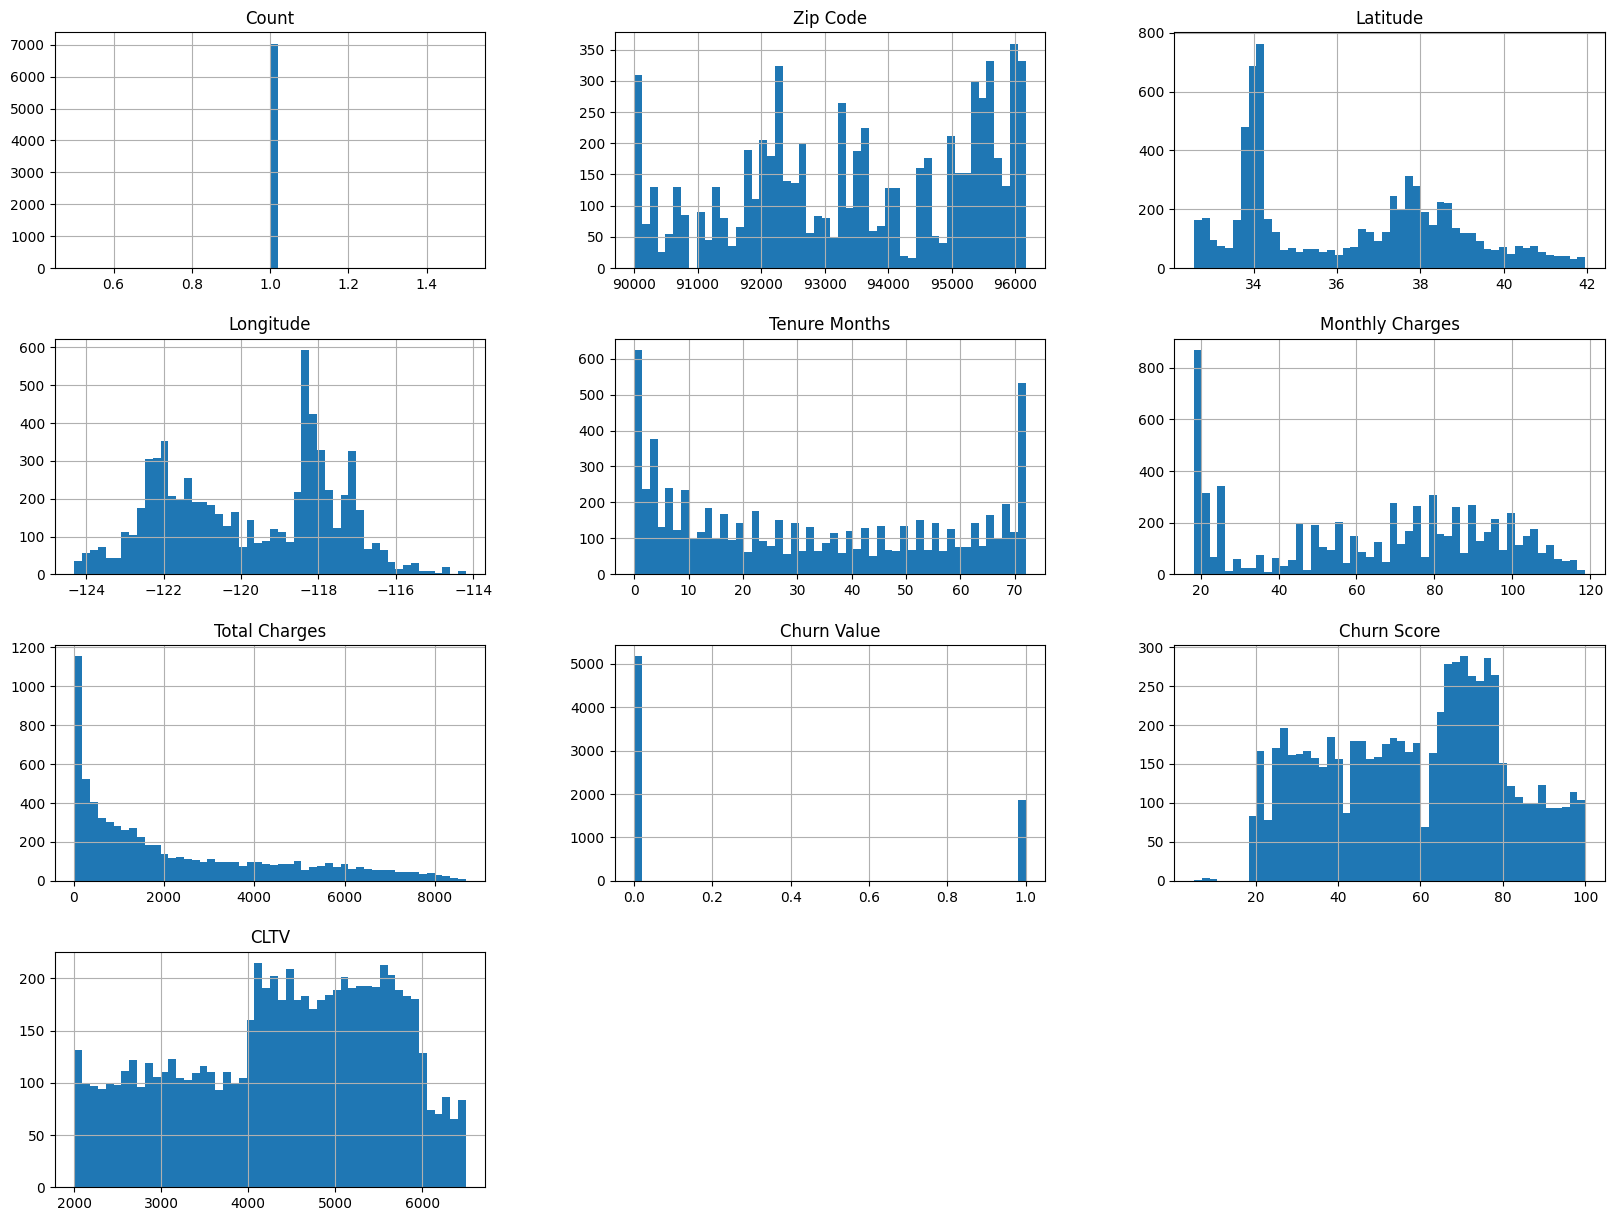

In [20]:
df.hist(figsize=(20, 15), bins=50) 

Count                 Axes(0.125,0.653529;0.168478x0.226471)
Zip Code           Axes(0.327174,0.653529;0.168478x0.226471)
Latitude           Axes(0.529348,0.653529;0.168478x0.226471)
Longitude          Axes(0.731522,0.653529;0.168478x0.226471)
Tenure Months         Axes(0.125,0.381765;0.168478x0.226471)
Monthly Charges    Axes(0.327174,0.381765;0.168478x0.226471)
Total Charges      Axes(0.529348,0.381765;0.168478x0.226471)
Churn Value        Axes(0.731522,0.381765;0.168478x0.226471)
Churn Score               Axes(0.125,0.11;0.168478x0.226471)
CLTV                   Axes(0.327174,0.11;0.168478x0.226471)
dtype: object

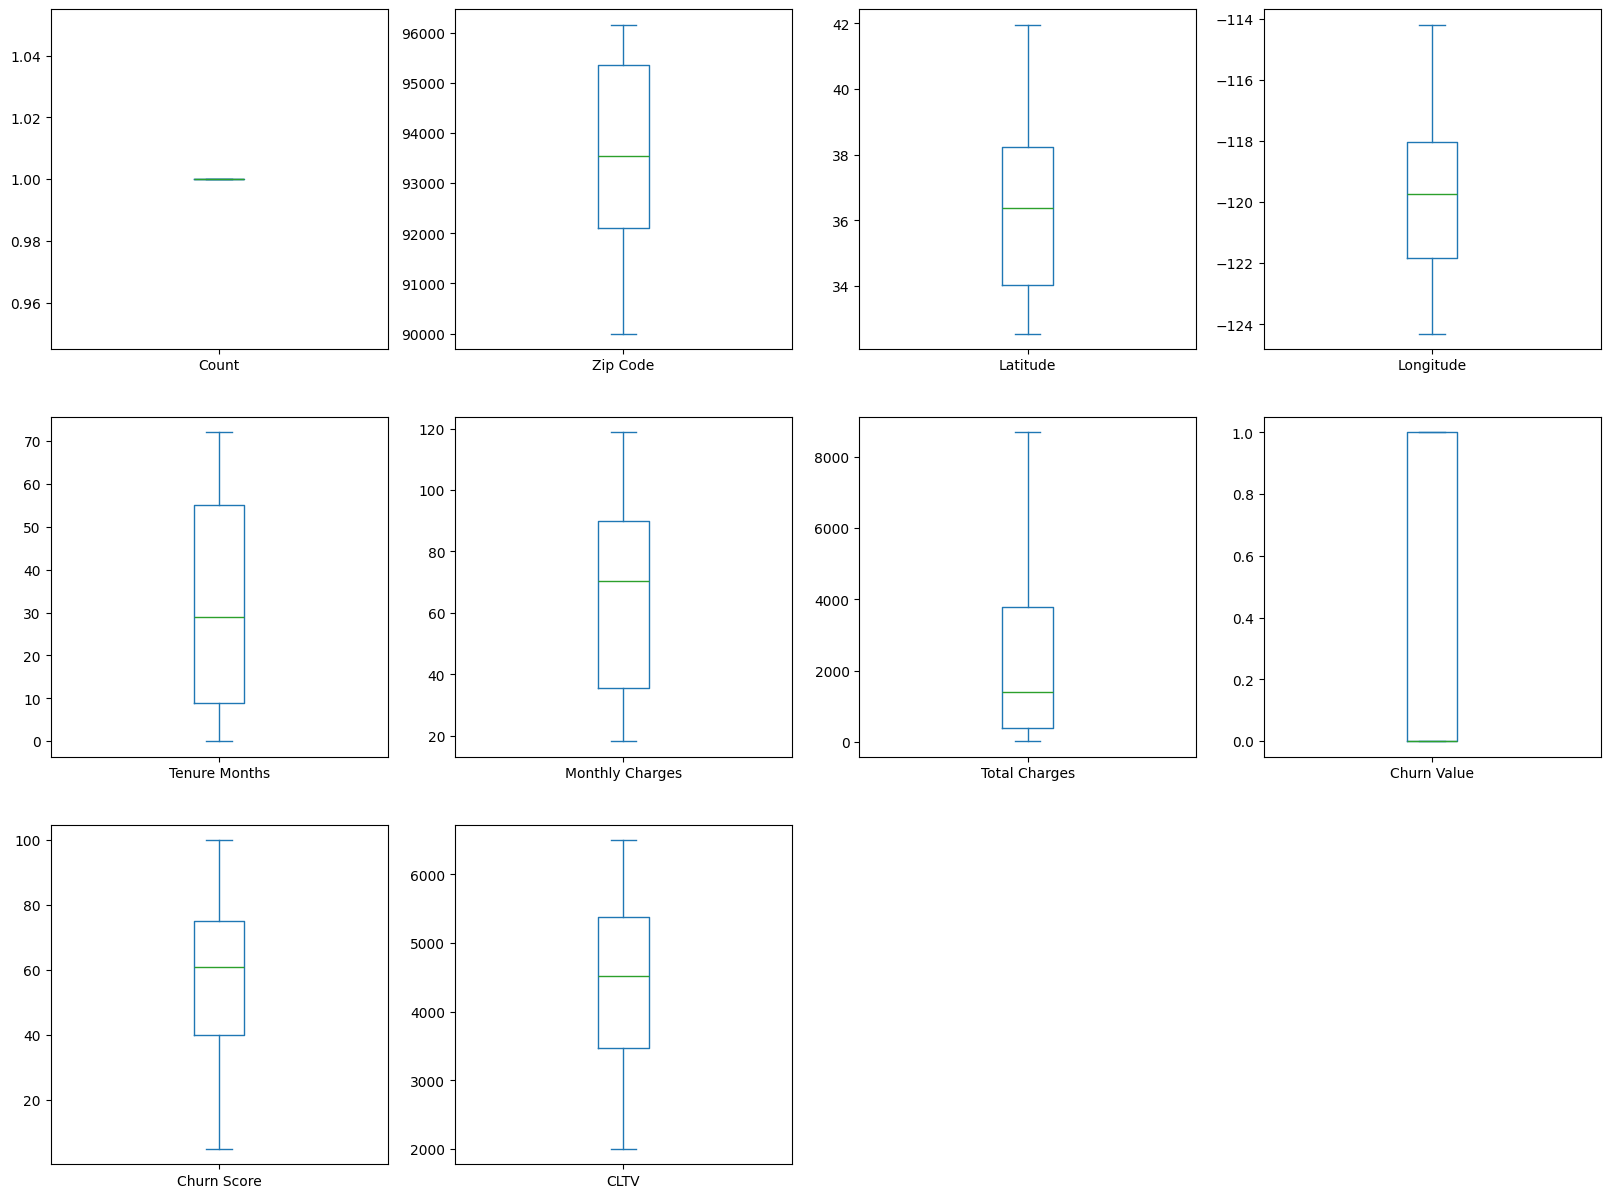

In [22]:
df.plot(kind='box', figsize=(20, 15), subplots=True, sharex=False, sharey=False, layout=(3, 4))

- No hay variables normales
- No hay valores atipicos 

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [24]:
for var in cat_vars:
    print('\n')
    print(df[var].value_counts())



Gender
Male      3555
Female    3488
Name: count, dtype: int64


Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


Partner
No     3641
Yes    3402
Name: count, dtype: int64


Dependents
No     5416
Yes    1627
Name: count, dtype: int64


Phone Service
Yes    6361
No      682
Name: count, dtype: int64


Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


Online Backup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64


Device Protection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64


Tech Support
No                     3473
Yes                    2044
N

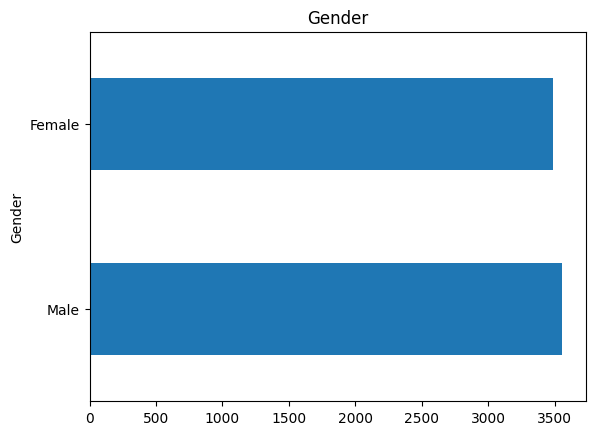

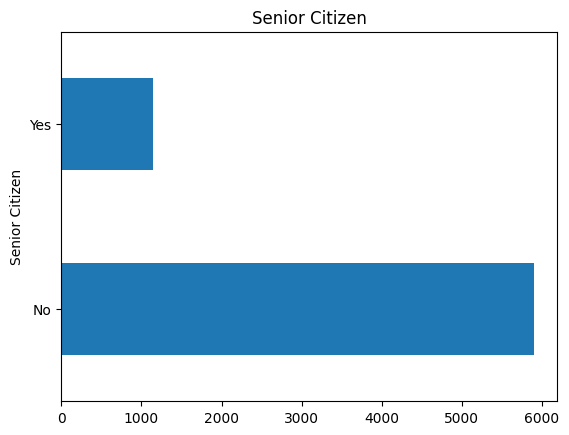

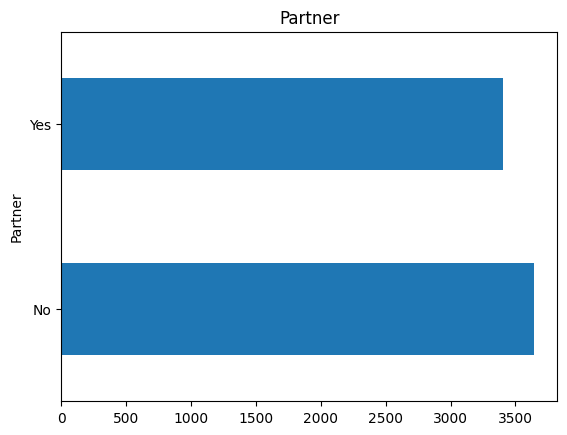

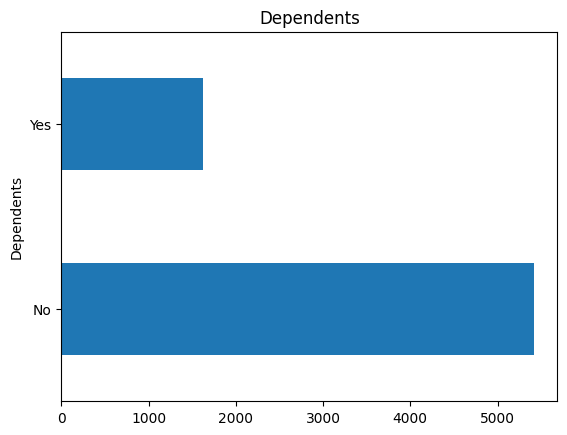

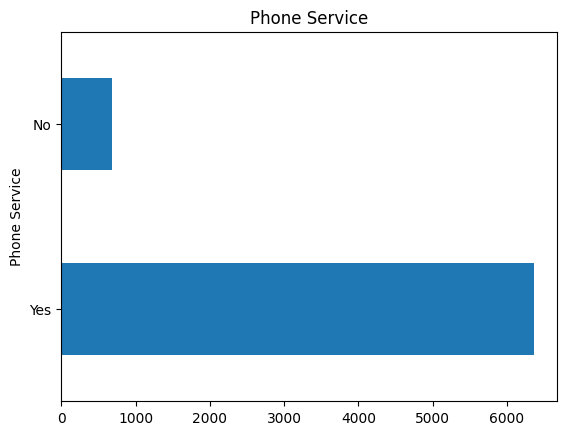

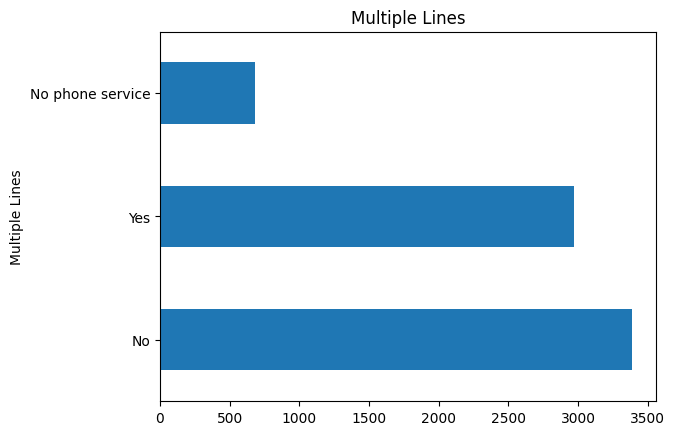

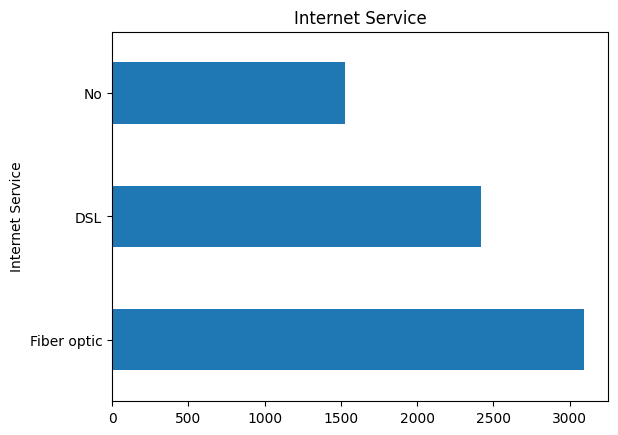

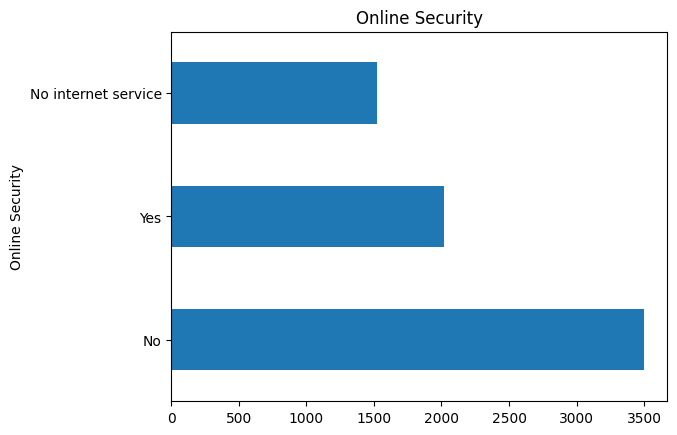

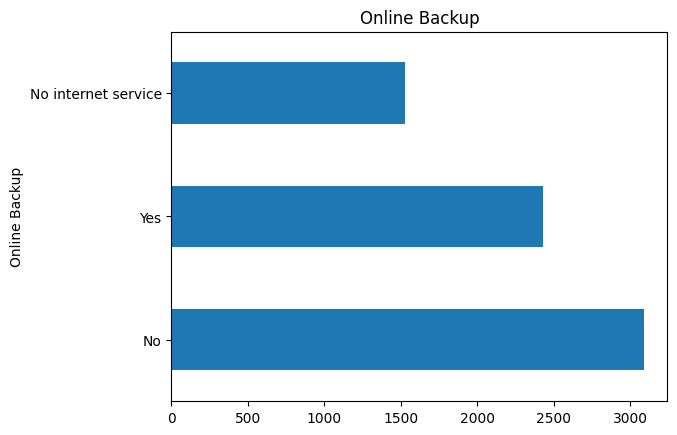

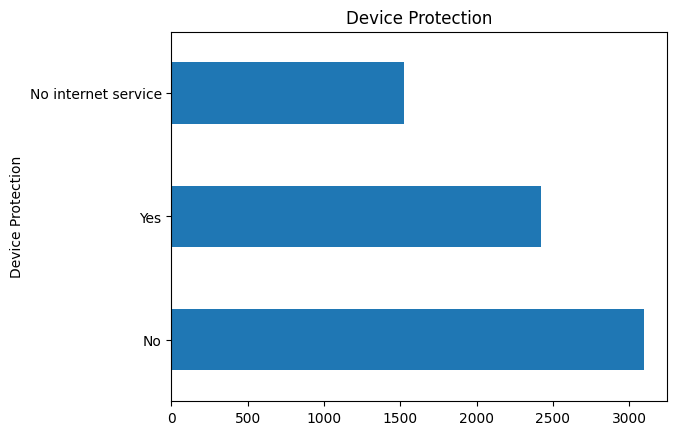

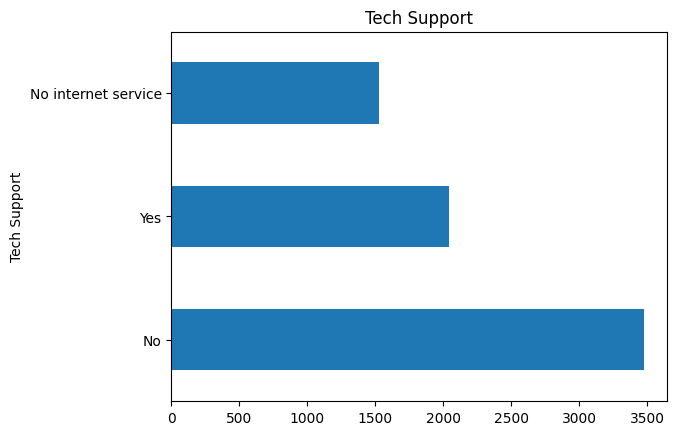

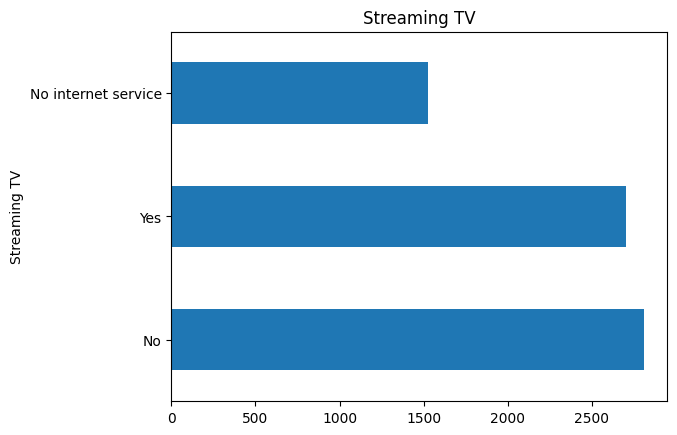

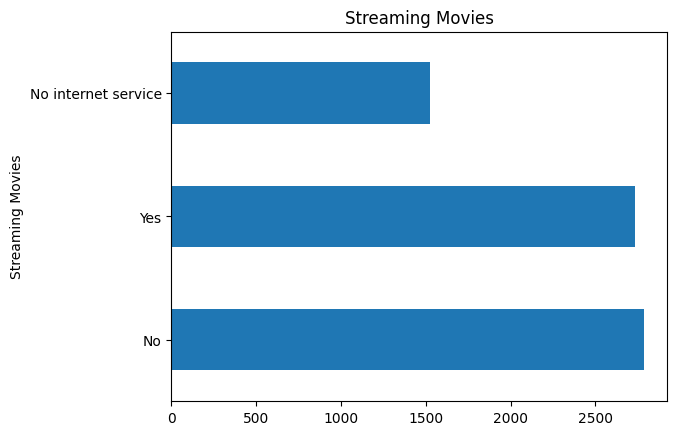

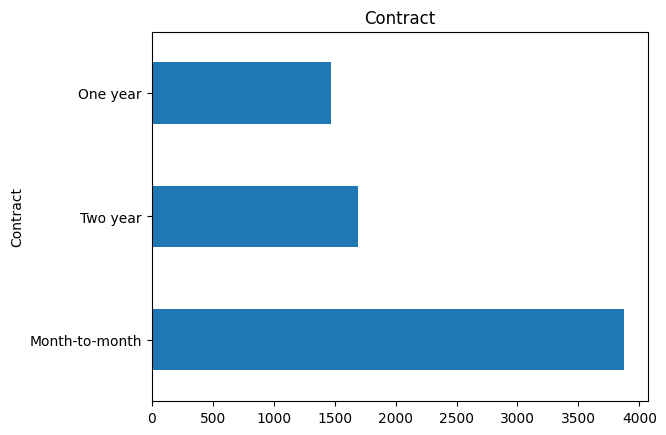

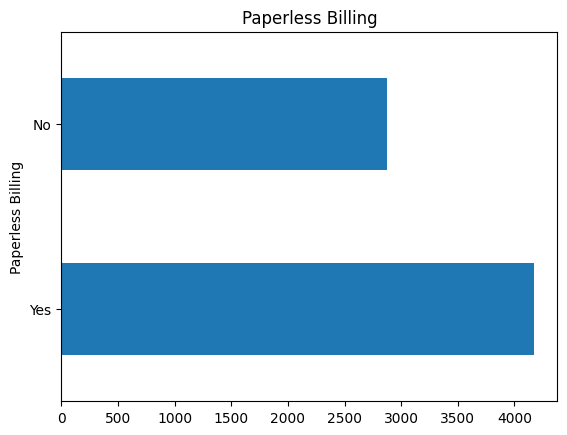

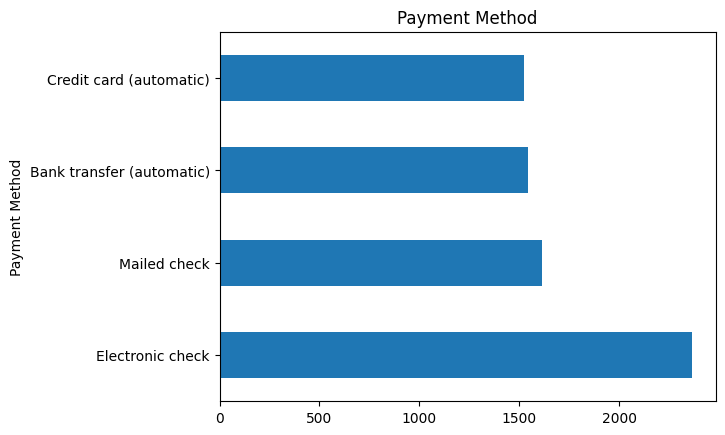

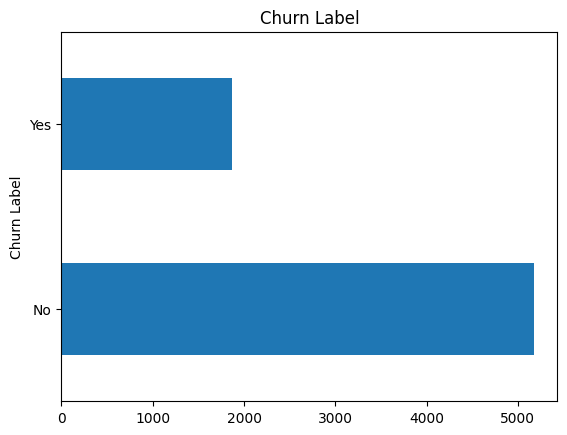

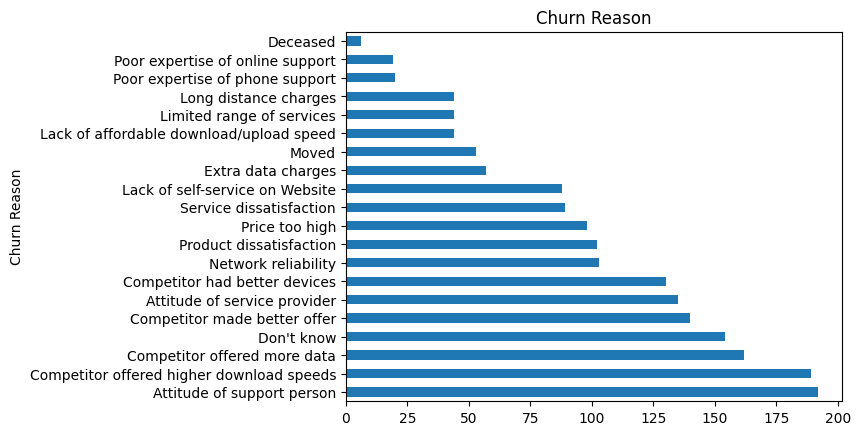

In [23]:
import matplotlib.pyplot as plt
cat_vars

for var in cat_vars:
    df[var].value_counts().plot(kind='barh')
    plt.title(var)
    plt.show()

- Bien distribuidas en general. Variables binarias con algunos desbalances notables (Senior Citizen 84% No, Phone Service 90% Yes). Churn Label típicamente desbalanceado (73% No churn). Varias variables tienen la categoría "No internet service" (1526), lo que muestra redundancia.
- Sí: Churn Reason con 20 categorías. Las demás tienen 2-4 categorías. Churn Reason tiene muchas categorías muy infrecuentes y es solo aplicable a clientes con churn, por lo que es candidata a agruparse o excluirse del modelo.
- Churn Reason: "Deceased" (6 registros) y "Poor expertise..." (19-20) — muy infrecuentes
Categorías "No internet/phone service" — codifican redundantemente información de otra variable

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


In [32]:
num_vars = df.drop(columns=['Count', 'Churn Value']).select_dtypes(include='number').columns
print(num_vars)

Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Score', 'CLTV'],
      dtype='object')


<Figure size 640x480 with 0 Axes>

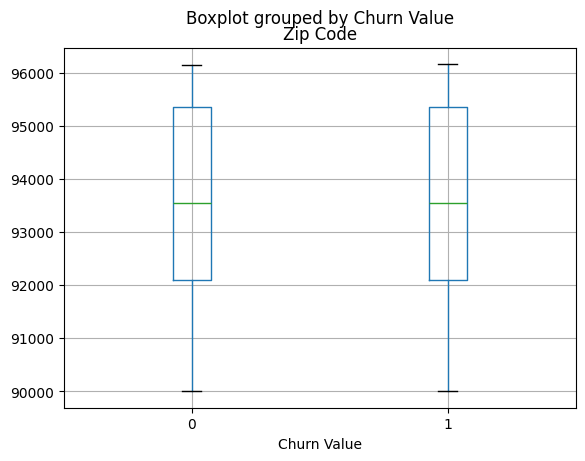

<Figure size 640x480 with 0 Axes>

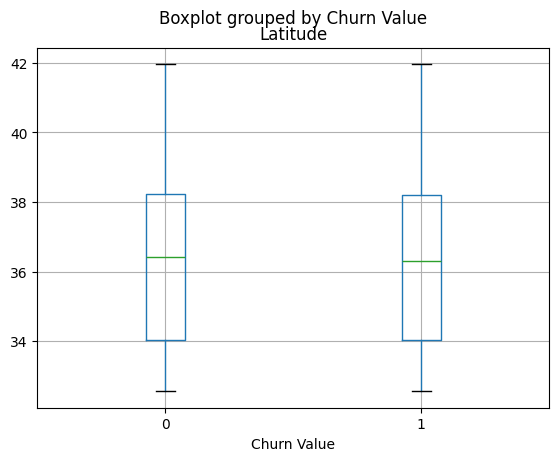

<Figure size 640x480 with 0 Axes>

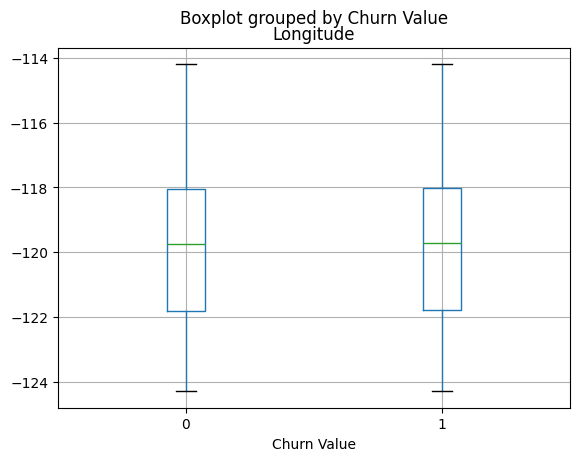

<Figure size 640x480 with 0 Axes>

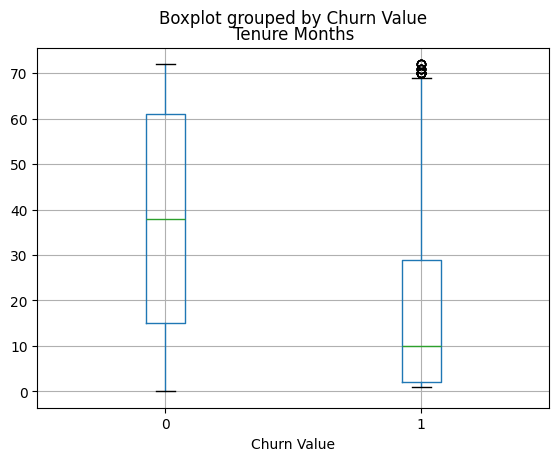

<Figure size 640x480 with 0 Axes>

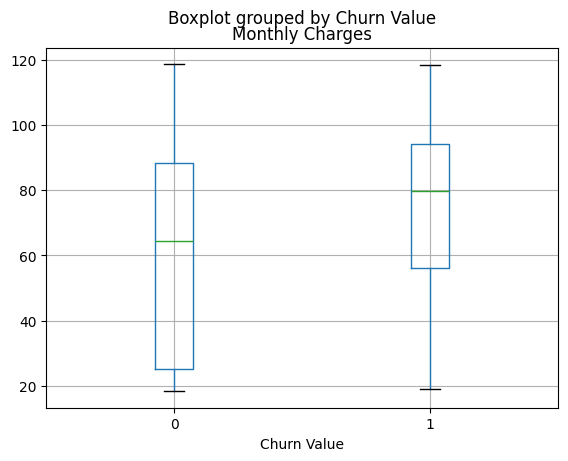

<Figure size 640x480 with 0 Axes>

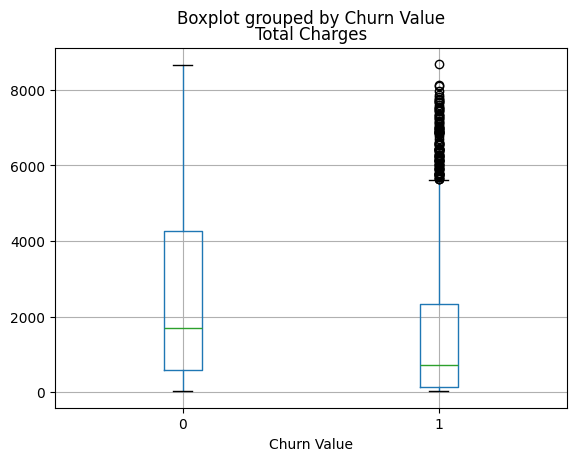

<Figure size 640x480 with 0 Axes>

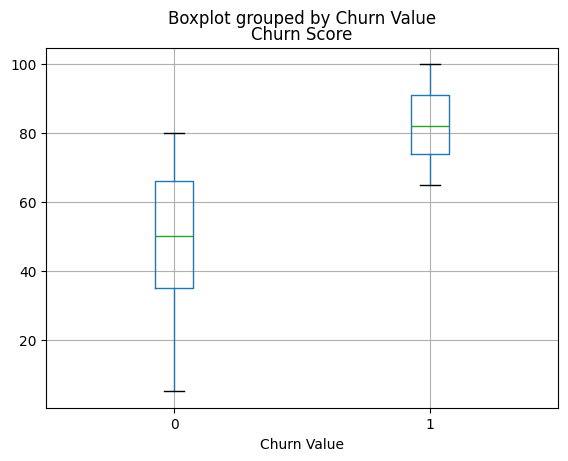

<Figure size 640x480 with 0 Axes>

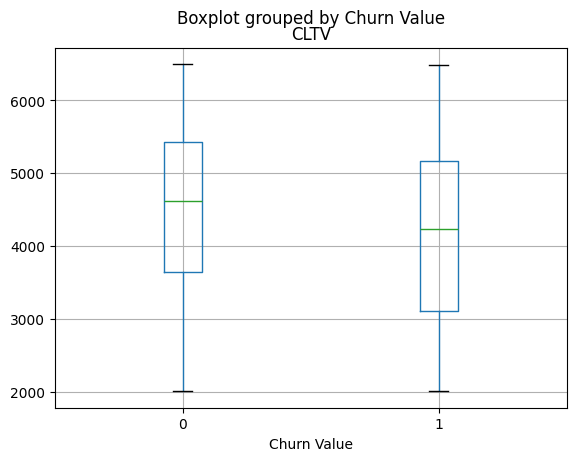

In [33]:
import seaborn as sns

for var in num_vars:
    plt.figure()
    df.boxplot(by='Churn Value', column=var)
    plt.show()

In [34]:
cat_vars

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')

In [36]:
#tablas de contingencia
for var in cat_vars:
    tabla = pd.crosstab(df[var], df['Churn Value'], normalize='index')
    print(f'{var}:')
    print(tabla)
    print('\n')


Gender:
Churn Value         0         1
Gender                         
Female       0.730791  0.269209
Male         0.738397  0.261603


Senior Citizen:
Churn Value            0         1
Senior Citizen                    
No              0.763938  0.236062
Yes             0.583187  0.416813


Partner:
Churn Value         0         1
Partner                        
No           0.670420  0.329580
Yes          0.803351  0.196649


Dependents:
Churn Value         0         1
Dependents                     
No           0.674483  0.325517
Yes          0.934849  0.065151


Phone Service:
Churn Value           0         1
Phone Service                    
No             0.750733  0.249267
Yes            0.732904  0.267096


Multiple Lines:
Churn Value              0         1
Multiple Lines                      
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099


Internet Service:
Churn Value              0         1
Internet Ser

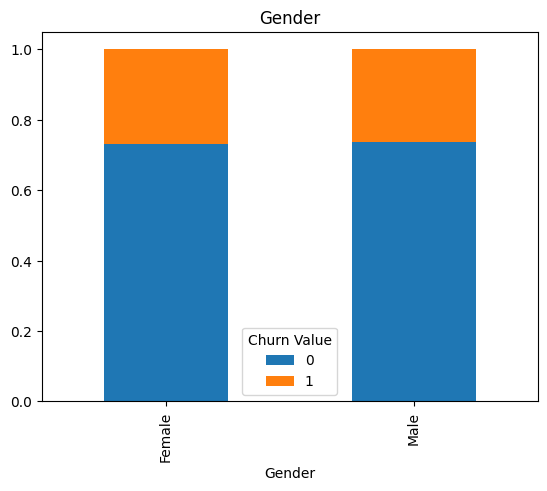

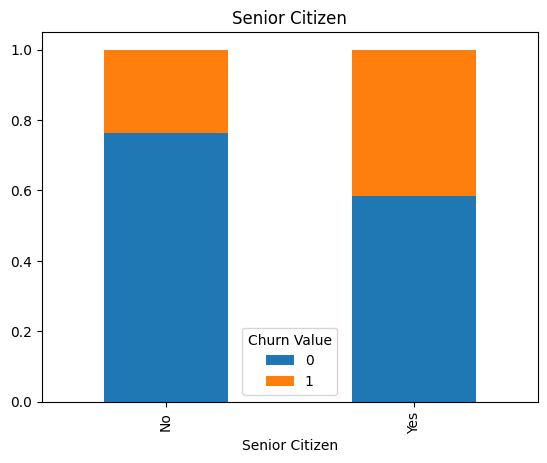

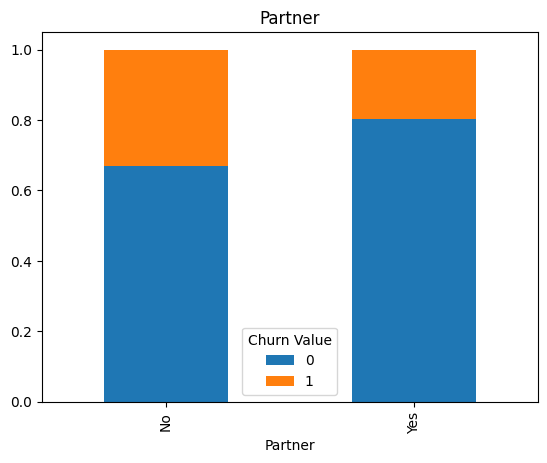

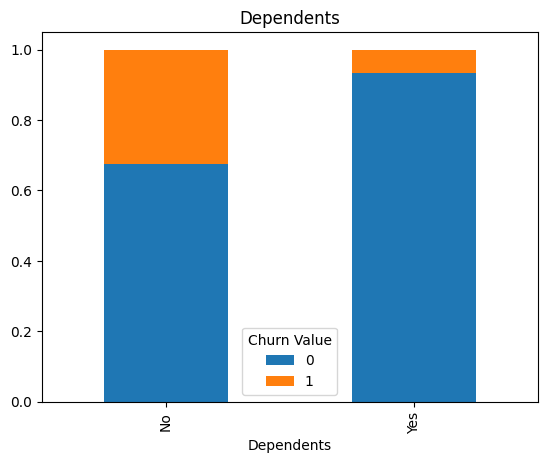

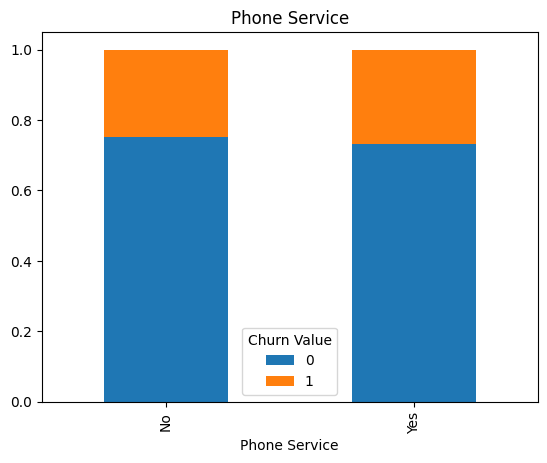

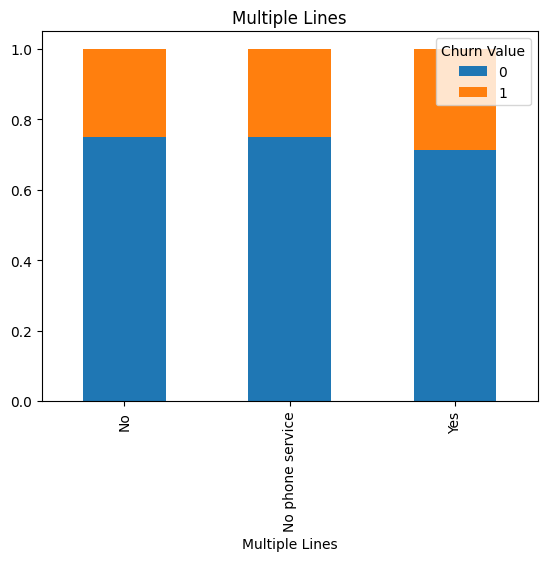

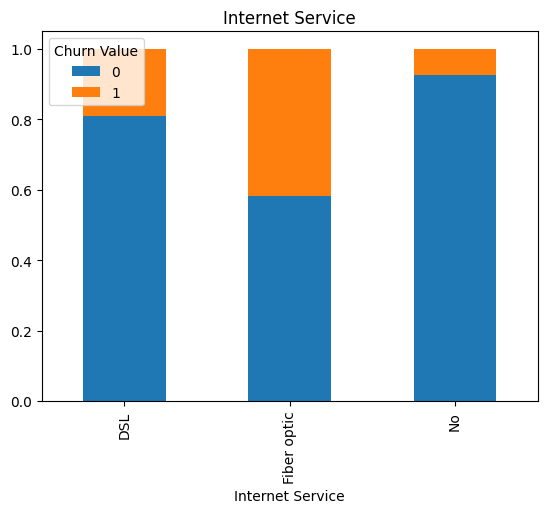

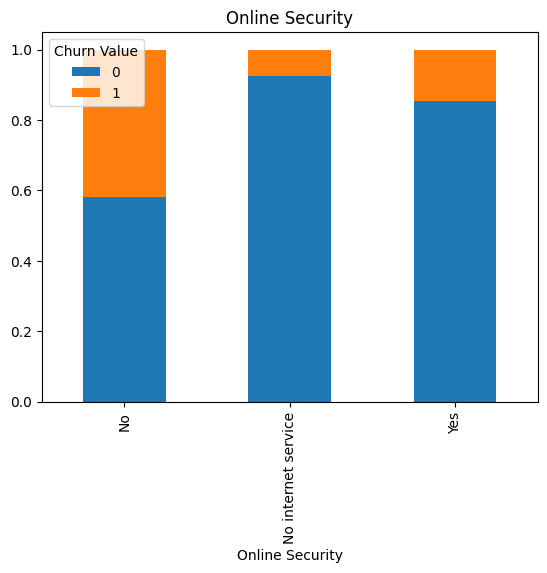

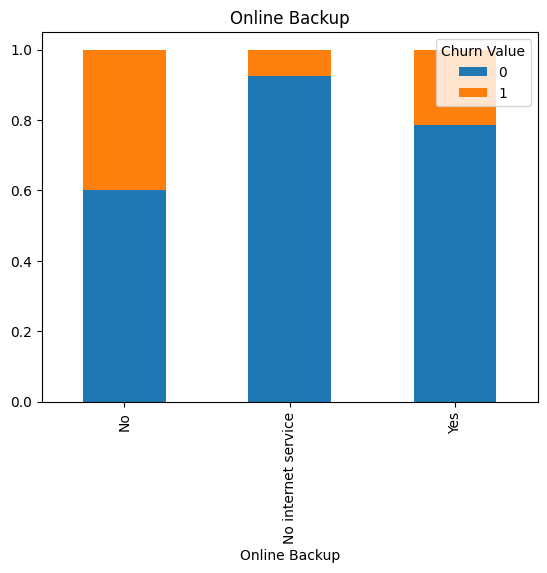

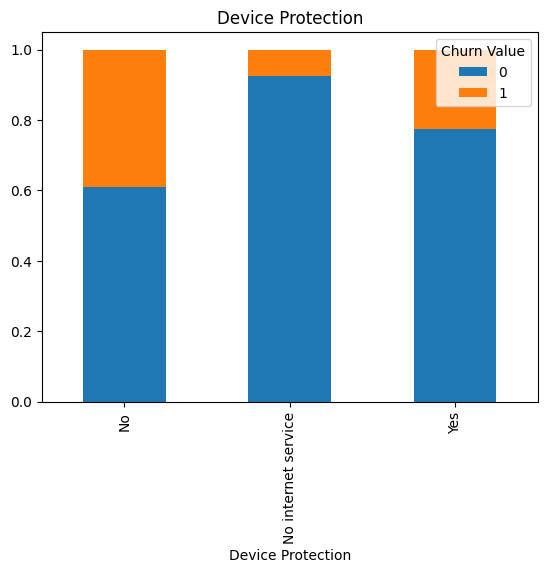

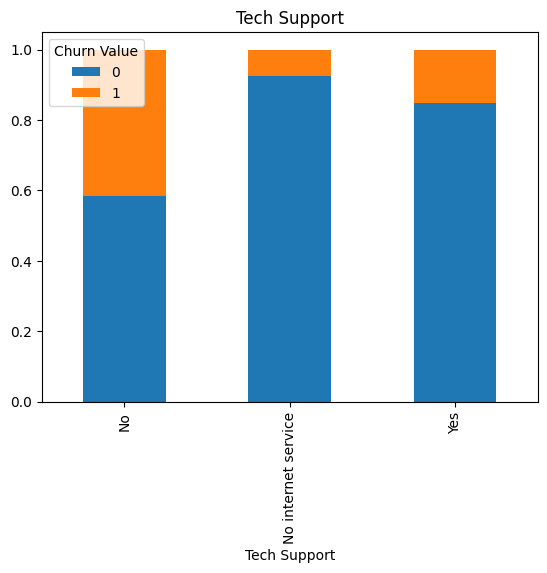

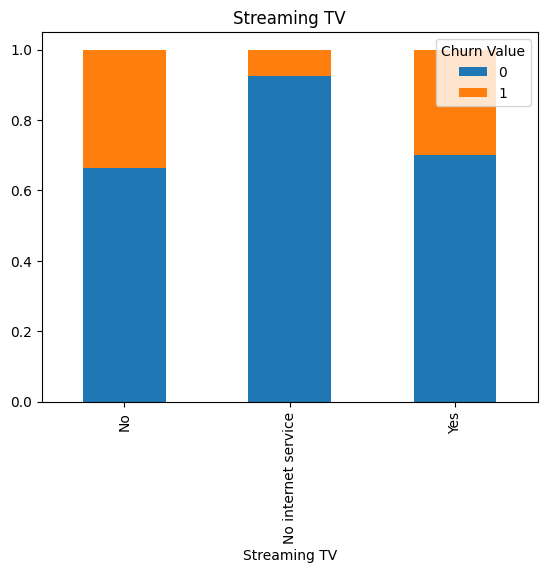

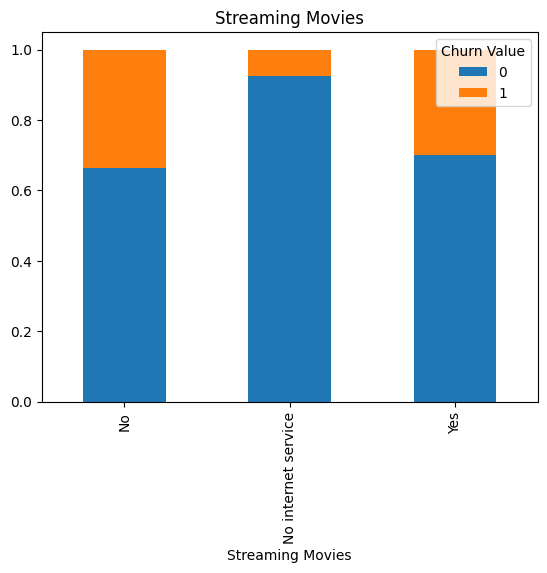

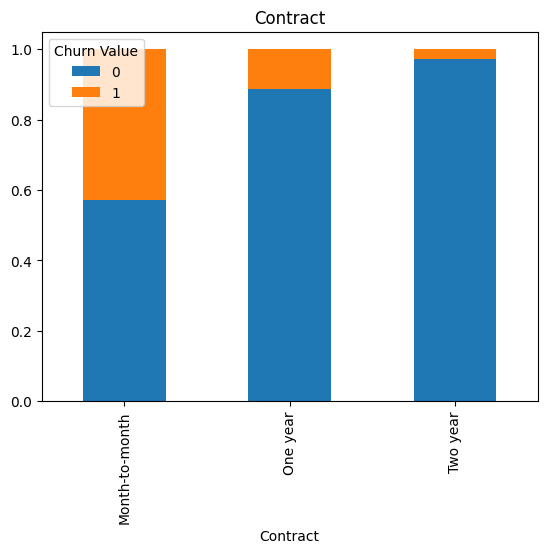

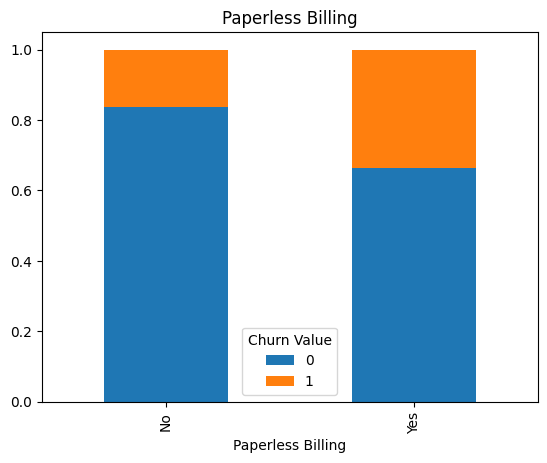

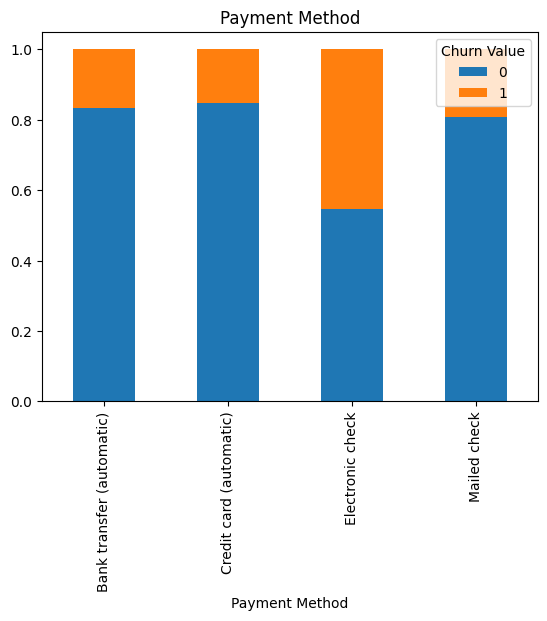

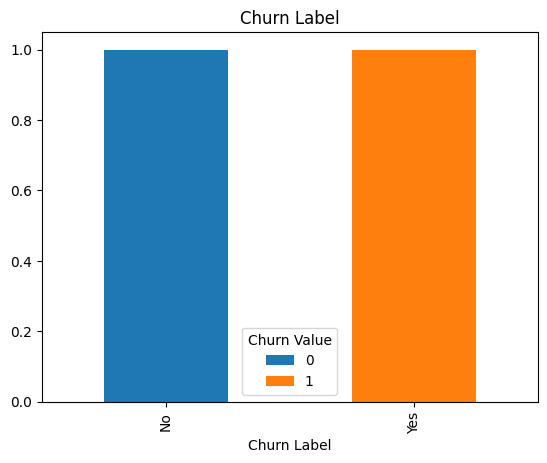

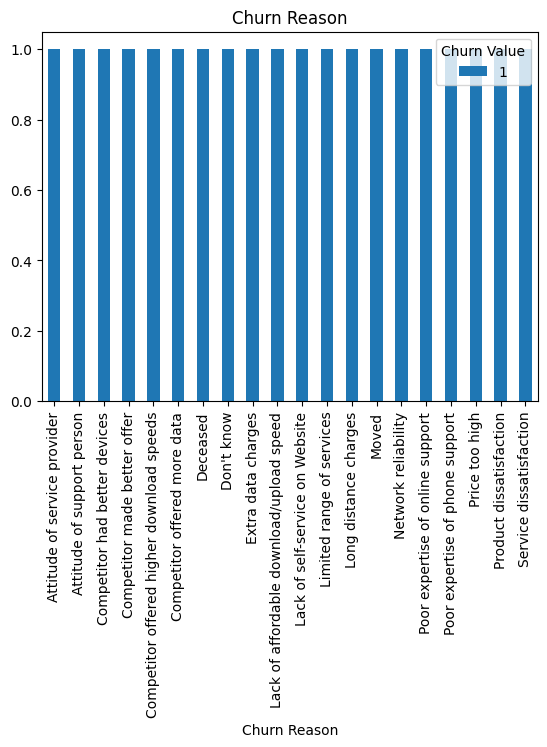

In [37]:
for var in cat_vars:
    tabla = pd.crosstab(df[var], df['Churn Value'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

- La relación de las cuantitativas se pueden ver en los botxplot, para cada variable cuantitativa, se evalúa si existe separación visual clara entre sus distribuciones para Churn=0 y Churn=1. A mayor separación, mejor predictora. A mayor similitud, peor predictora.
- Se hizo la relación con tablas de contingencia, en el caso por ejemplo de la variable 'Senior Citizen' nos puede dar un indicio de que las personas mayores se retiran, mientras que por ejemplo en sexo se ve una similitud entre el si y el no, lo que significa que no es una buena predictoria 
- Al ser muy similares los boxplot o la tabla de contingencia no se discrimina quienes se van y quienes no, por ejemplo zip code,longitude no son buenas predictorias. Por otro lado buenas predictorias como churn score 